## Masked Autoencoders: Visualization Demo

This is a visualization demo using our pre-trained MAE models. No GPU is needed.

### Prepare
Check environment. Install packages if in Colab.


In [6]:
import sys
import os
from pathlib import Path
import requests

import torch
import numpy as np

import matplotlib.pyplot as plt
from PIL import Image

# check whether run in Colab
if 'google.colab' in sys.modules:
    print('Running in Colab.')
    !pip3 install timm==0.4.5  # 0.3.2 does not work in Colab
    !git clone https://github.com/facebookresearch/mae.git
    sys.path.insert(0, './mae')
else:
    # known remote workspace path
    fallback_root = Path('/home/yl241/workspace/Masked-Autoencoder')
    if fallback_root.is_dir() and (fallback_root / 'src/utils/masked_autoencoder/models_mae.py').is_file():
        repo_root = fallback_root
    else:
        cwd = Path.cwd().resolve()
        repo_root = None
        for cand in [cwd, *cwd.parents]:
            if (cand / 'src/utils/masked_autoencoder/models_mae.py').is_file() and (cand / 'src/utils/masked_autoencoder/util').is_dir():
                repo_root = cand
                break
        if repo_root is None:
            raise ModuleNotFoundError(
                f'Cannot find repo root from cwd={cwd}. Tried fallback={fallback_root}.'
            )
    sys.path.insert(0, str(repo_root))
    print(f'Using repo root: {repo_root}')

from src.utils.masked_autoencoder import models_mae



Using repo root: /home/yl241/workspace/Masked-Autoencoder


### Define utils

In [7]:
# define the utils

imagenet_mean = np.array([0.485, 0.456, 0.406])
imagenet_std = np.array([0.229, 0.224, 0.225])

def show_image(image, title=''):
    # image is [H, W, 3]
    assert image.shape[2] == 3
    plt.imshow(torch.clip((image * imagenet_std + imagenet_mean) * 255, 0, 255).int())
    plt.title(title, fontsize=16)
    plt.axis('off')
    return

def prepare_model(chkpt_dir, arch='mae_vit_large_patch16', strict='auto'):
    # build model
    model = getattr(models_mae, arch)()

    # load model state dict
    checkpoint = torch.load(chkpt_dir, map_location='cpu')
    state_dict = checkpoint['model'] if isinstance(checkpoint, dict) and 'model' in checkpoint else checkpoint
    msg = model.load_state_dict(state_dict, strict=False)
    print(msg)

    decoder_prefixes = ('decoder_', 'decoder_blocks')
    decoder_exact = {'mask_token'}
    decoder_missing = [
        k for k in msg.missing_keys if k in decoder_exact or k.startswith(decoder_prefixes)
    ]
    other_missing = [k for k in msg.missing_keys if k not in decoder_missing]

    # strict mode for full compatibility checks
    if strict is True and (len(msg.missing_keys) > 0 or len(msg.unexpected_keys) > 0):
        raise RuntimeError(
            f'Checkpoint/arch mismatch for arch={arch}: '
            f'missing={len(msg.missing_keys)}, unexpected={len(msg.unexpected_keys)}'
        )

    # auto mode: allow encoder-only MAE checkpoints, fail on other mismatches
    encoder_only_ckpt = len(decoder_missing) > 0 and len(other_missing) == 0 and len(msg.unexpected_keys) == 0
    if strict == 'auto':
        if len(other_missing) > 0 or len(msg.unexpected_keys) > 0:
            raise RuntimeError(
                f'Checkpoint/arch mismatch for arch={arch}: '
                f'other_missing={len(other_missing)}, unexpected={len(msg.unexpected_keys)}'
            )
        if encoder_only_ckpt:
            print('Warning: encoder-only checkpoint loaded (no decoder weights).')
            print('Masked-token reconstruction will look noisy/random.')

    model._encoder_only_ckpt = encoder_only_ckpt
    model.eval()
    return model

def run_one_image(img, model):
    x = torch.tensor(img)

    # make it a batch-like
    x = x.unsqueeze(dim=0)
    x = torch.einsum('nhwc->nchw', x)

    # run MAE
    with torch.no_grad():
        loss, y, mask = model(x.float(), mask_ratio=0.75)
    y = model.unpatchify(y)
    y = torch.einsum('nchw->nhwc', y).detach().cpu()

    # visualize the mask
    mask = mask.detach()
    mask = mask.unsqueeze(-1).repeat(1, 1, model.patch_embed.patch_size[0]**2 * 3)  # (N, H*W, p*p*3)
    mask = model.unpatchify(mask)  # 1 is removing, 0 is keeping
    mask = torch.einsum('nchw->nhwc', mask).detach().cpu()

    x = torch.einsum('nchw->nhwc', x)

    # masked image
    im_masked = x * (1 - mask)

    # MAE reconstruction pasted with visible patches
    im_paste = x * (1 - mask) + y * mask

    # make the plt figure larger
    plt.rcParams['figure.figsize'] = [24, 24]

    plt.subplot(1, 4, 1)
    show_image(x[0], 'original')

    plt.subplot(1, 4, 2)
    show_image(im_masked[0], 'masked')

    plt.subplot(1, 4, 3)
    show_image(y[0], 'reconstruction')

    plt.subplot(1, 4, 4)
    show_image(im_paste[0], 'reconstruction + visible')

    plt.show()



### Load an image

In [8]:
# load an image
img_url = 'https://user-images.githubusercontent.com/11435359/147738734-196fd92f-9260-48d5-ba7e-bf103d29364d.jpg' # fox, from ILSVRC2012_val_00046145
# img_url = 'https://user-images.githubusercontent.com/11435359/147743081-0428eecf-89e5-4e07-8da5-a30fd73cc0ba.jpg' # cucumber, from ILSVRC2012_val_00047851
img = Image.open(requests.get(img_url, stream=True).raw)
img = img.resize((224, 224))
img = np.array(img) / 255.

assert img.shape == (224, 224, 3)

# normalize by ImageNet mean and std
img = img - imagenet_mean
img = img / imagenet_std

plt.rcParams['figure.figsize'] = [5, 5]
show_image(torch.tensor(img))
plt.imshow()

/tmp/ipykernel_2039909/3566912957.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.imshow(torch.clip((image * imagenet_std + imagenet_mean) * 255, 0, 255).int())


### Load a pre-trained MAE model

In [9]:
# This is an MAE model trained with pixels as targets for visualization (ViT-Large, training mask ratio=0.75)

# download checkpoint if not exist
!wget -nc https://dl.fbaipublicfiles.com/mae/visualize/mae_visualize_vit_large.pth

chkpt_dir = 'mae_visualize_vit_large.pth'
model_mae = prepare_model(chkpt_dir, 'mae_vit_large_patch16')
print('Model loaded.')


--2026-03-07 13:33:01--  https://dl.fbaipublicfiles.com/mae/visualize/mae_visualize_vit_large.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 143.204.130.57, 143.204.130.61, 143.204.130.97, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|143.204.130.57|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1318315181 (1.2G) [binary/octet-stream]
Saving to: ‘mae_visualize_vit_large.pth’

mae_visualize_vit_l 100%[===================>]   1.23G   326MB/s    in 4.0s    

2026-03-07 13:33:05 (313 MB/s) - ‘mae_visualize_vit_large.pth’ saved [1318315181/1318315181]

<All keys matched successfully>
Model loaded.


### Run MAE on the image

MAE with pixel reconstruction:


/tmp/ipykernel_2039909/3566912957.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.imshow(torch.clip((image * imagenet_std + imagenet_mean) * 255, 0, 255).int())


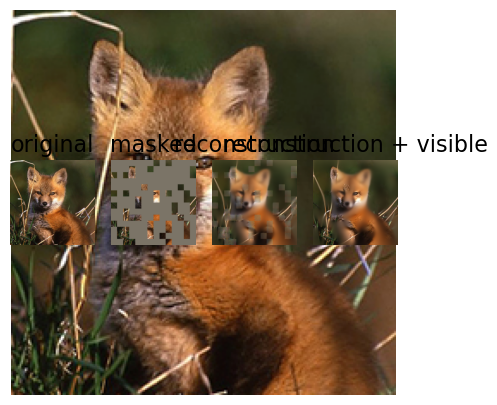

In [10]:
# make random mask reproducible (comment out to make it change)
torch.manual_seed(2)
print('MAE with pixel reconstruction:')
run_one_image(img, model_mae)
plt.imshow()

### Load another pre-trained MAE model

In [11]:
# This is an MAE model trained with an extra GAN loss for more realistic generation (ViT-Large, training mask ratio=0.75)

# download checkpoint if not exist
!wget -nc https://dl.fbaipublicfiles.com/mae/visualize/mae_visualize_vit_large_ganloss.pth

chkpt_dir = 'mae_visualize_vit_large_ganloss.pth'
model_mae_gan = prepare_model('mae_visualize_vit_large_ganloss.pth', 'mae_vit_large_patch16')
print('Model loaded.')

--2026-03-07 13:33:10--  https://dl.fbaipublicfiles.com/mae/visualize/mae_visualize_vit_large_ganloss.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 143.204.130.61, 143.204.130.97, 143.204.130.57, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|143.204.130.61|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1318315181 (1.2G) [binary/octet-stream]
Saving to: ‘mae_visualize_vit_large_ganloss.pth’

mae_visualize_vit_l 100%[===================>]   1.23G   367MB/s    in 3.4s    

2026-03-07 13:33:14 (365 MB/s) - ‘mae_visualize_vit_large_ganloss.pth’ saved [1318315181/1318315181]

<All keys matched successfully>
Model loaded.


### Run MAE on the image

MAE with extra GAN loss:


/tmp/ipykernel_2039909/3566912957.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.imshow(torch.clip((image * imagenet_std + imagenet_mean) * 255, 0, 255).int())


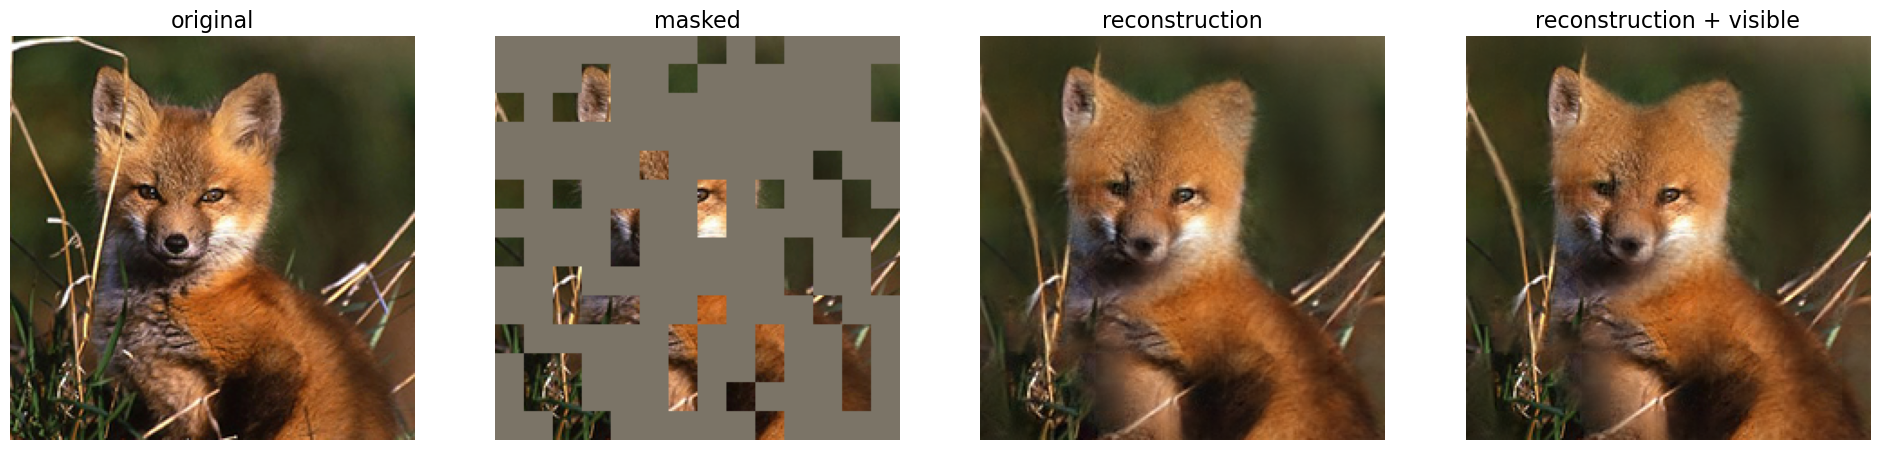

In [12]:
# make random mask reproducible (comment out to make it change)
torch.manual_seed(2)
print('MAE with extra GAN loss:')
run_one_image(img, model_mae_gan)
plt.imshow()

## ViT-base

In [15]:
# smallest official MAE checkpoint
!wget -nc https://dl.fbaipublicfiles.com/mae/pretrain/mae_pretrain_vit_base.pth

chkpt_dir = "mae_pretrain_vit_base.pth"
model_mae_base = prepare_model("mae_pretrain_vit_base.pth", "mae_vit_base_patch16")

print("ViT-Base model loaded.")

# then use your existing visualization call
# run_one_image(img, model_mae_base)


File ‘mae_pretrain_vit_base.pth’ already there; not retrieving.

_IncompatibleKeys(missing_keys=['mask_token', 'decoder_pos_embed', 'decoder_embed.weight', 'decoder_embed.bias', 'decoder_blocks.0.norm1.weight', 'decoder_blocks.0.norm1.bias', 'decoder_blocks.0.attn.qkv.weight', 'decoder_blocks.0.attn.qkv.bias', 'decoder_blocks.0.attn.proj.weight', 'decoder_blocks.0.attn.proj.bias', 'decoder_blocks.0.norm2.weight', 'decoder_blocks.0.norm2.bias', 'decoder_blocks.0.mlp.fc1.weight', 'decoder_blocks.0.mlp.fc1.bias', 'decoder_blocks.0.mlp.fc2.weight', 'decoder_blocks.0.mlp.fc2.bias', 'decoder_blocks.1.norm1.weight', 'decoder_blocks.1.norm1.bias', 'decoder_blocks.1.attn.qkv.weight', 'decoder_blocks.1.attn.qkv.bias', 'decoder_blocks.1.attn.proj.weight', 'decoder_blocks.1.attn.proj.bias', 'decoder_blocks.1.norm2.weight', 'decoder_blocks.1.norm2.bias', 'decoder_blocks.1.mlp.fc1.weight', 'decoder_blocks.1.mlp.fc1.bias', 'decoder_blocks.1.mlp.fc2.weight', 'decoder_blocks.1.mlp.fc2.bias', 'decoder_b

RuntimeError: Checkpoint/arch mismatch for arch=mae_vit_base_patch16: missing=104, unexpected=0

In [ ]:
# load ViT-Base checkpoint
chkpt_dir = "mae_pretrain_vit_base.pth"
model_mae_base = prepare_model(chkpt_dir, "mae_vit_base_patch16")
model_mae_base.eval()

# visualize
run_one_image(img, model_mae_base)
plt.imshow()
